In [1]:
## IMPORTS 
import os
import sys 
LOCSCALE_2_SCRIPTS_PATH = "/home/abharadwaj1/papers/publications/2025_LocScale_2"
PLOT_DATA_STORE_PATH = "/home/abharadwaj1/papers/elife_paper/figure_information/archive_data/organized/data"
sys.path.append(LOCSCALE_2_SCRIPTS_PATH)
from scripts.utils.plot_utils import *

import numpy as np
import random
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
from scipy import stats
import pandas as pd
import seaborn as sns
from scripts.utils.plot_utils import plot_correlations
from scripts.utils.general import setup_environment, create_folders_if_they_do_not_exist

random.seed(42)
np.random.seed(42)

## Supplementary 5 a

In [6]:
# num_residues_outside_training_data = "/home/abharadwaj1/papers/elife_paper/figure_information/archive_data/outputs/model_angelo/num_residues_outside_training_data.json"
# num_residues_training_outside = pd.read_json(num_residues_outside_training_data)
# num_residues_training_outside["locscale_advantage_before_pruning"] = num_residues_training_outside["num_residues_difference_before_pruning"] > 0
# num_residues_training_outside["locscale_advantage_after_pruning"] = num_residues_training_outside["num_residues_difference_after_pruning"] > 0

save_path_outside_training_data = os.path.join(PLOT_DATA_STORE_PATH, "s5_a_num_residues_outside_training_data.csv")
# num_residues_training_outside.to_csv(save_path_outside_training_data, index=True)

num_residues_training_outside = pd.read_csv(save_path_outside_training_data, index_col=0)


In [3]:
# sort num_residues_training based on num_residues_difference_before_pruning
num_residues_outside_training_sorted_before_pruning = num_residues_training_outside.copy(deep=True)
num_residues_outside_training_sorted_before_pruning = num_residues_outside_training_sorted_before_pruning.sort_values(by="num_residues_difference_before_pruning", ascending=False)
order_before_pruning_outside_training = num_residues_outside_training_sorted_before_pruning["emdb_list_ordered"]
# sort num_residues_training based on num_residues_difference_after_pruning
num_residues_outside_training_sorted_after_pruning = num_residues_training_outside.copy(deep=True)
num_residues_outside_training_sorted_after_pruning = num_residues_outside_training_sorted_after_pruning.sort_values(by="num_residues_difference_after_pruning", ascending=False)
order_after_pruning_outside_training = num_residues_outside_training_sorted_after_pruning["emdb_list_ordered"]


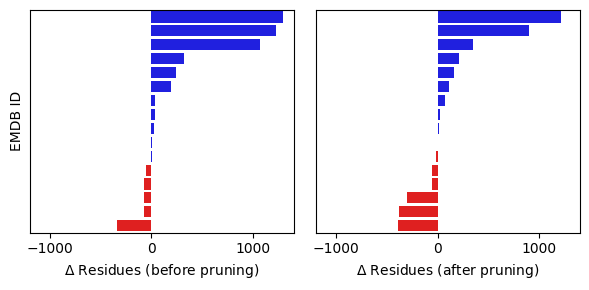

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(6, 3))
sns.barplot(data=num_residues_outside_training_sorted_before_pruning, \
            x="num_residues_difference_before_pruning", y="emdb_list_ordered", hue="locscale_advantage_before_pruning", \
            palette={True: "blue", False: "red"}, orient="h", dodge=False, \
            order=order_before_pruning_outside_training, ax=ax[0])

sns.barplot(data=num_residues_outside_training_sorted_after_pruning, \
            x="num_residues_difference_after_pruning", y="emdb_list_ordered", hue="locscale_advantage_after_pruning", \
            palette={True: "blue", False: "red"}, orient="h", dodge=False, \
            order=order_after_pruning_outside_training, ax=ax[1])

# hide y axis labels for both subplots
ax[0].set_ylabel("EMDB ID")
ax[1].set_ylabel("")
ax[0].set_yticks([]);
ax[1].set_yticks([]);
ax[0].set_xlim([-1200, 1400])
ax[1].set_xlim([-1200, 1400])
ax[0].set_xticks([-1000, 0, 1000])
ax[1].set_xticks([-1000, 0, 1000])
ax[0].set_xlabel("$\\Delta$ Residues (before pruning)")
ax[1].set_xlabel("$\\Delta$ Residues (after pruning)")
ax[0].legend_.remove()
ax[1].legend_.remove()

plt.tight_layout()

## Supplementary 5 b

In [7]:
# num_residues_training_data = "/home/abharadwaj1/papers/elife_paper/figure_information/archive_data/outputs/model_angelo/num_residues_inside_training_data.json"
# num_residues_training = pd.read_json(num_residues_training_data)
# num_residues_training["locscale_advantage_before_pruning"] = num_residues_training["num_residues_difference_before_pruning"] > 0
# num_residues_training["locscale_advantage_after_pruning"] = num_residues_training["num_residues_difference_after_pruning"] > 0

save_path_training_data = os.path.join(PLOT_DATA_STORE_PATH, "s5_b_num_residues_training_data.csv")
# num_residues_training.to_csv(save_path_training_data, index=True)

num_residues_training = pd.read_csv(save_path_training_data, index_col=0)


In [8]:
# sort num_residues_training based on num_residues_difference_before_pruning
num_residues_training_sorted_before_pruning = num_residues_training.copy(deep=True)
num_residues_training_sorted_before_pruning = num_residues_training_sorted_before_pruning.sort_values(by="num_residues_difference_before_pruning", ascending=False)
order_before_pruning = num_residues_training_sorted_before_pruning["emdb_list_ordered"]
# sort num_residues_training based on num_residues_difference_after_pruning
num_residues_training_sorted_after_pruning = num_residues_training.copy(deep=True)
num_residues_training_sorted_after_pruning = num_residues_training_sorted_after_pruning.sort_values(by="num_residues_difference_after_pruning", ascending=False)
order_after_pruning = num_residues_training_sorted_after_pruning["emdb_list_ordered"]


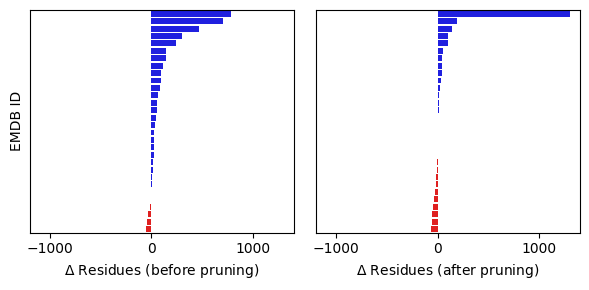

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(6, 3))
sns.barplot(data=num_residues_training_sorted_before_pruning, \
            x="num_residues_difference_before_pruning", y="emdb_list_ordered", hue="locscale_advantage_before_pruning", \
            palette={True: "blue", False: "red"}, orient="h", dodge=False, \
            order=order_before_pruning, ax=ax[0])

sns.barplot(data=num_residues_training_sorted_after_pruning, \
            x="num_residues_difference_after_pruning", y="emdb_list_ordered", hue="locscale_advantage_after_pruning", \
            palette={True: "blue", False: "red"}, orient="h", dodge=False, \
            order=order_after_pruning, ax=ax[1])

# hide y axis labels for both subplots
ax[0].set_ylabel("EMDB ID")
ax[1].set_ylabel("")
ax[0].set_yticks([]);
ax[1].set_yticks([]);
ax[0].set_xlim([-1200, 1400])
ax[1].set_xlim([-1200, 1400])
ax[0].set_xticks([-1000, 0, 1000])
ax[1].set_xticks([-1000, 0, 1000])
ax[0].set_xlabel("$\\Delta$ Residues (before pruning)")
ax[1].set_xlabel("$\\Delta$ Residues (after pruning)")
ax[0].legend_.remove()
ax[1].legend_.remove()

plt.tight_layout()

## Supplementary 4 f

In [10]:
outside_training_sequence_recall_csv_emdb = os.path.join(PLOT_DATA_STORE_PATH, "average_confusion_matrix_unsharpened_percentages.csv")
outside_training_sequence_recall_csv_locscale = os.path.join(PLOT_DATA_STORE_PATH, "average_confusion_matrix_hybrid_percentages.csv")
inside_training_sequence_recall_csv_emdb = os.path.join(PLOT_DATA_STORE_PATH, "average_confusion_matrix_unsharpened_percentagesin_training.csv")
inside_training_sequence_recall_csv_locscale = os.path.join(PLOT_DATA_STORE_PATH, "average_confusion_matrix_hybrid_percentages_in_training.csv")

# read csv files, ignore first column
sequence_recall_emdb_outside_training = pd.read_csv(outside_training_sequence_recall_csv_emdb, index_col=0)
sequence_recall_locscale_outside_training = pd.read_csv(outside_training_sequence_recall_csv_locscale, index_col=0)
sequence_recall_emdb_inside_training = pd.read_csv(inside_training_sequence_recall_csv_emdb, index_col=0)
sequence_recall_locscale_inside_training = pd.read_csv(inside_training_sequence_recall_csv_locscale, index_col=0)

<Axes: >

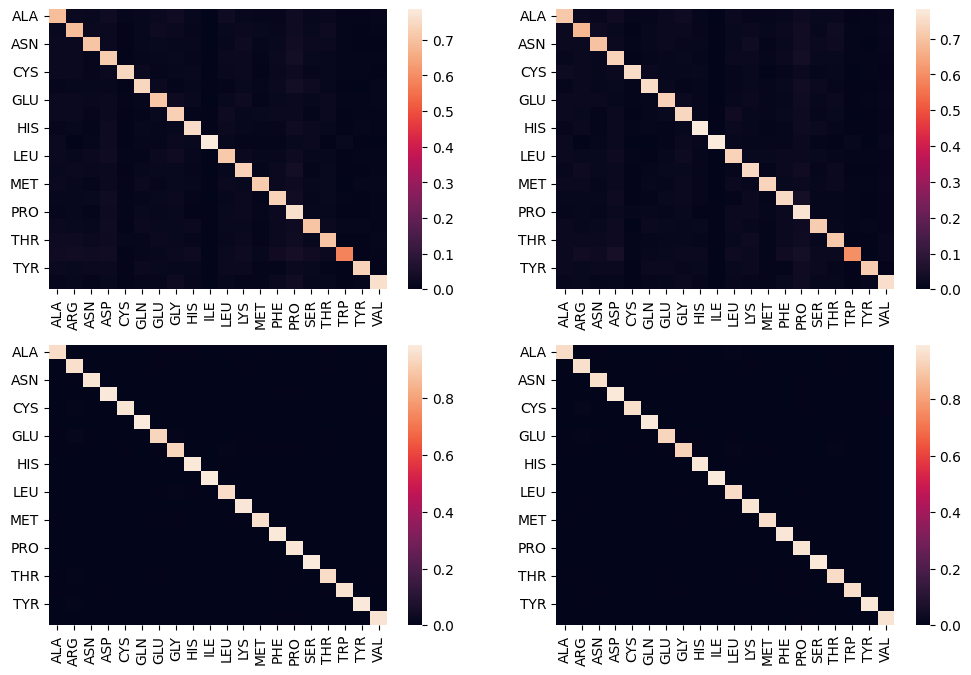

In [11]:
# plot seaborn heatmap for outside training data
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
sns.heatmap(sequence_recall_emdb_outside_training, ax=ax[0,0])
sns.heatmap(sequence_recall_locscale_outside_training, ax=ax[0,1])
sns.heatmap(sequence_recall_emdb_inside_training, ax=ax[1,0])
sns.heatmap(sequence_recall_locscale_inside_training, ax=ax[1,1])
